In [1]:
%pwd
%load_ext autoreload
%autoreload 2

In [2]:
from scripts.run_experiments import run_experiment
from scripts.experiment_utils import generate_experiments

In [3]:
base_config = {
    # Experiment
    "experiment": "toroidal_VAE",
    "random_seed": 42,
    "logging": True,

    # Dataset
    "dataset_name": "t2_synthetic",
    "batch_size": 64,
    "rotation": "random",
    "translation": None,
    "n_times": 2500,
    "embedding_dim": 10,
    "major_radius": 2,
    "minor_radius": 1,
    "noise_var": 0.001,
    "geodesic_distortion_amp": 0.0,

    # Model
    'model_type': 'VMToroidalVAE',
    'latent_dim': 2,
    'manifold_dim': 2,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [50,50,50],
    'decoder_widths': [50,50,50],

    # Optimizer
    "learning_rate": 0.001,

    # Trainer
    'verbose': False,
    'num_epochs': 50,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': False,
    'dim_topo_loss': 0,  # Max feature dimension topological loss
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': 0.0,  # Weight for KL loss
    'gamma': 1.0,  # Weight for topological loss

    # Curvature computation
    "plot_curvatures": False,
    "compute_true_curv": False,
    "compute_learned_curv": False,
    "compute_rec_curv": True,
    "quadric_dim": 1,
    "n_plot_points": 2500,
    "n_points_emp_curv": 1000,
    "n_points_pullback_curv": 1000, 
    "k": 110,
    "smoothing": False,

    # Persistent homology
    "persistent_homology": False,
    "n_points_pers_hom": 1000,
    "scale": False,
    "homology_dimensions": [0, 1]
}


param_grid = {
    'encoder_widths': ([[50] * 3, [100] * 3, [400] * 3]) * 2,
    'decoder_widths': ([[50] * 3, [100] * 3, [200] * 3]) * 2,
    'num_epochs': [400] * 6,
    'noise_var': [0.001] * 6,
    'activation': ['softplus'] * 3 + ['relu'] * 3,
}

all_configs = generate_experiments(base_config, param_grid)


Running exp00_toroidal_VAE. 
Description: encoder_widths=[50, 50, 50], decoder_widths=[50, 50, 50], num_epochs=400, noise_var=0.001, activation=softplus
--------------------------------------------------------------------------------------


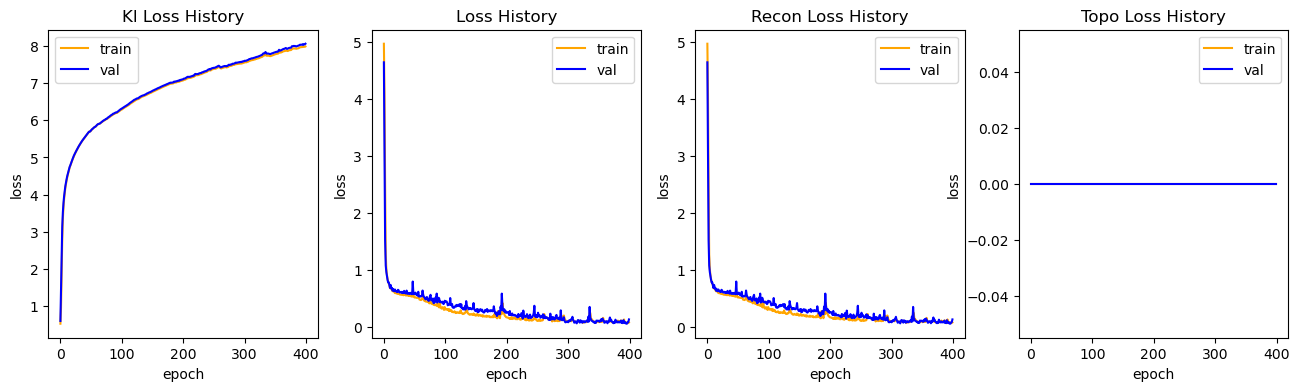

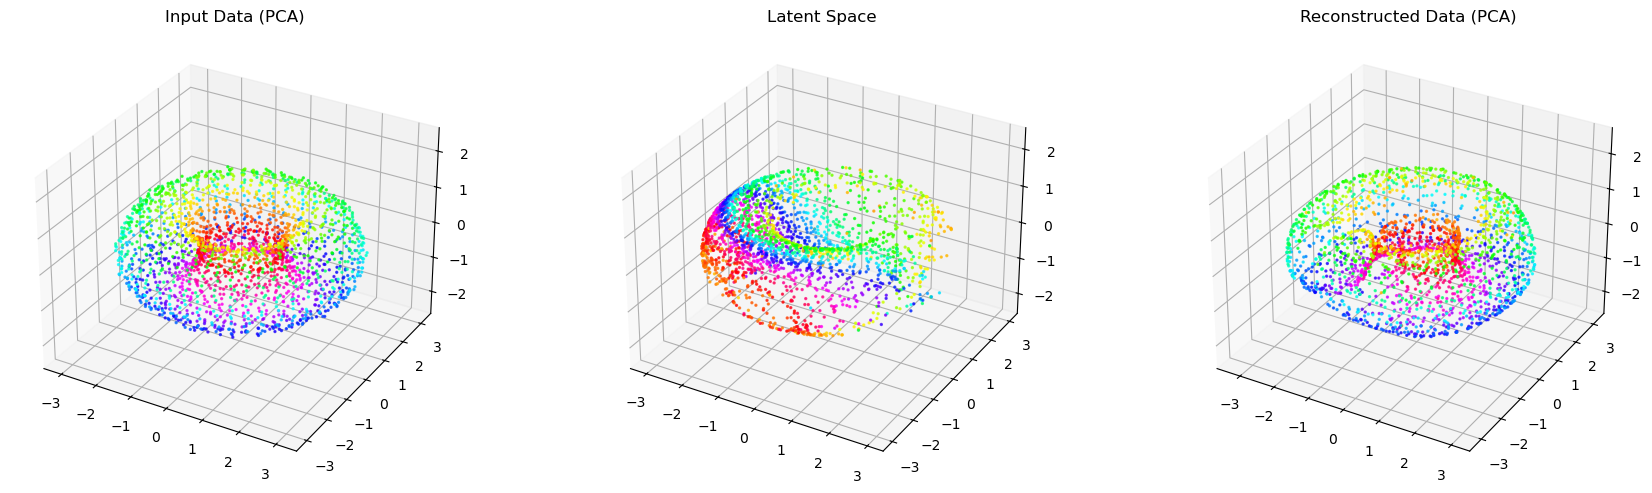

Execution time exp00_toroidal_VAE: 398.0165 seconds

Running exp01_toroidal_VAE. 
Description: encoder_widths=[100, 100, 100], decoder_widths=[100, 100, 100], num_epochs=400, noise_var=0.001, activation=softplus
--------------------------------------------------------------------------------------


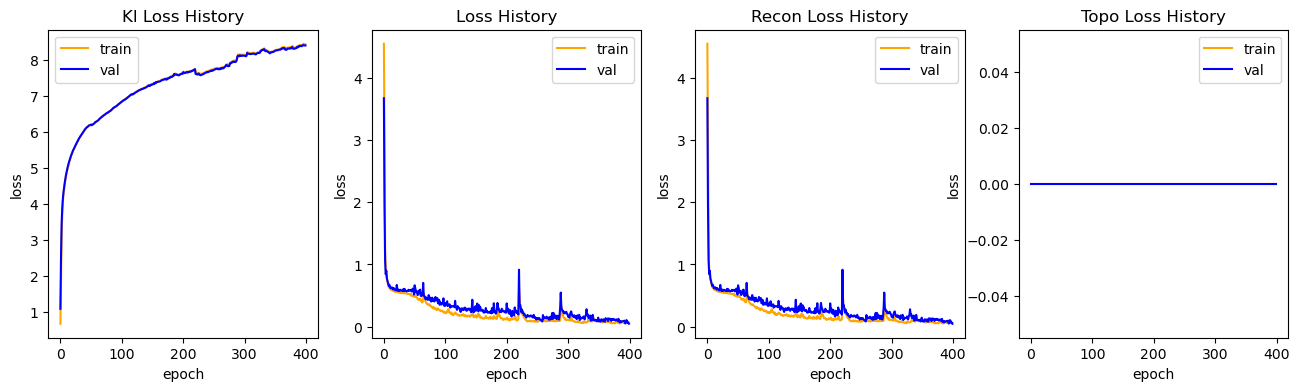

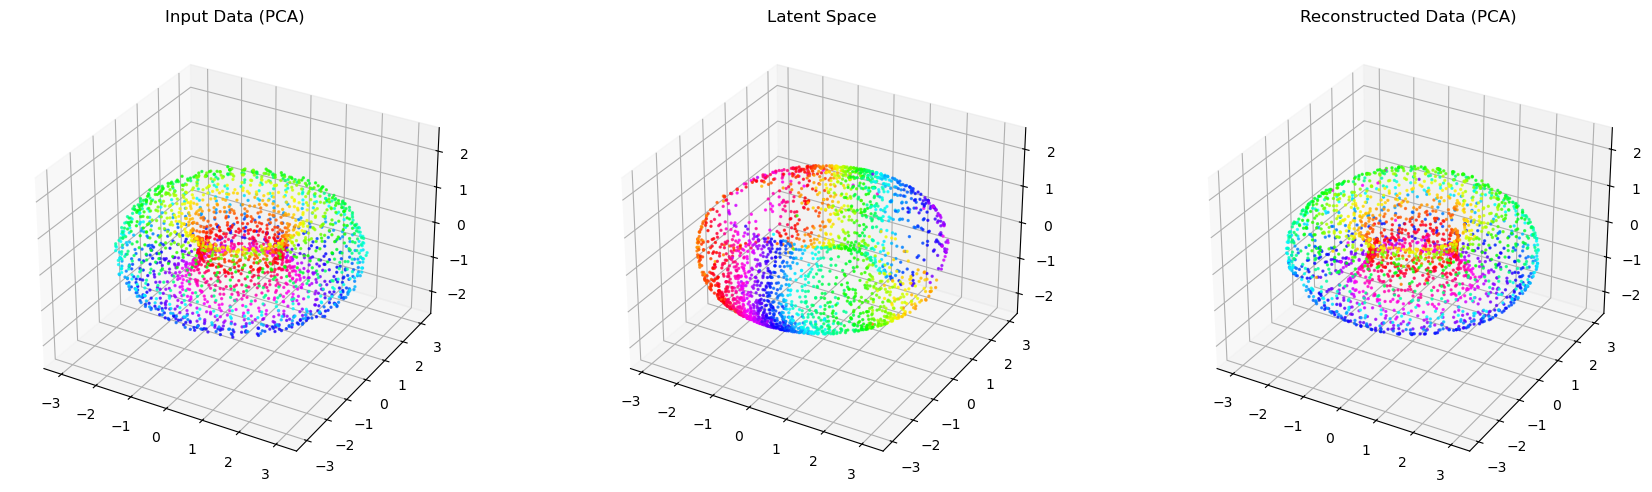

Execution time exp01_toroidal_VAE: 751.4464 seconds

Running exp02_toroidal_VAE. 
Description: encoder_widths=[400, 400, 400], decoder_widths=[200, 200, 200], num_epochs=400, noise_var=0.001, activation=softplus
--------------------------------------------------------------------------------------


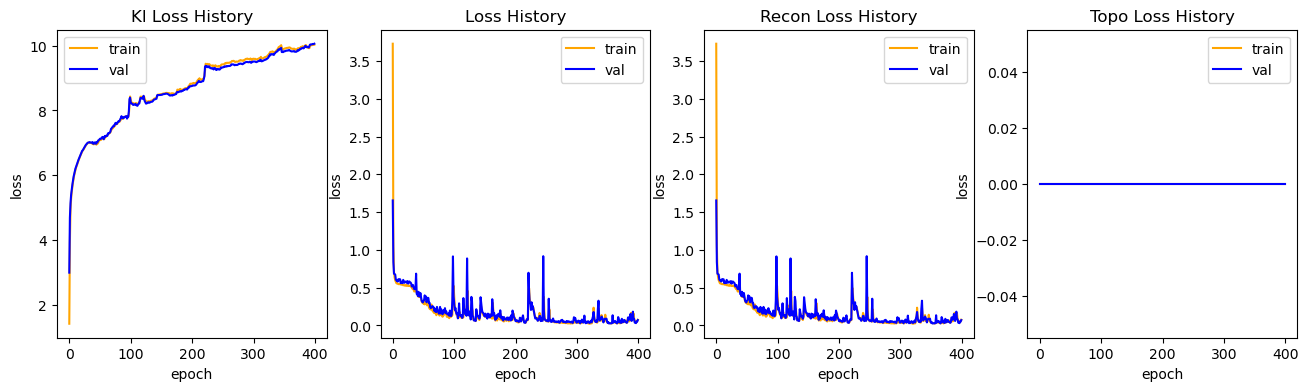

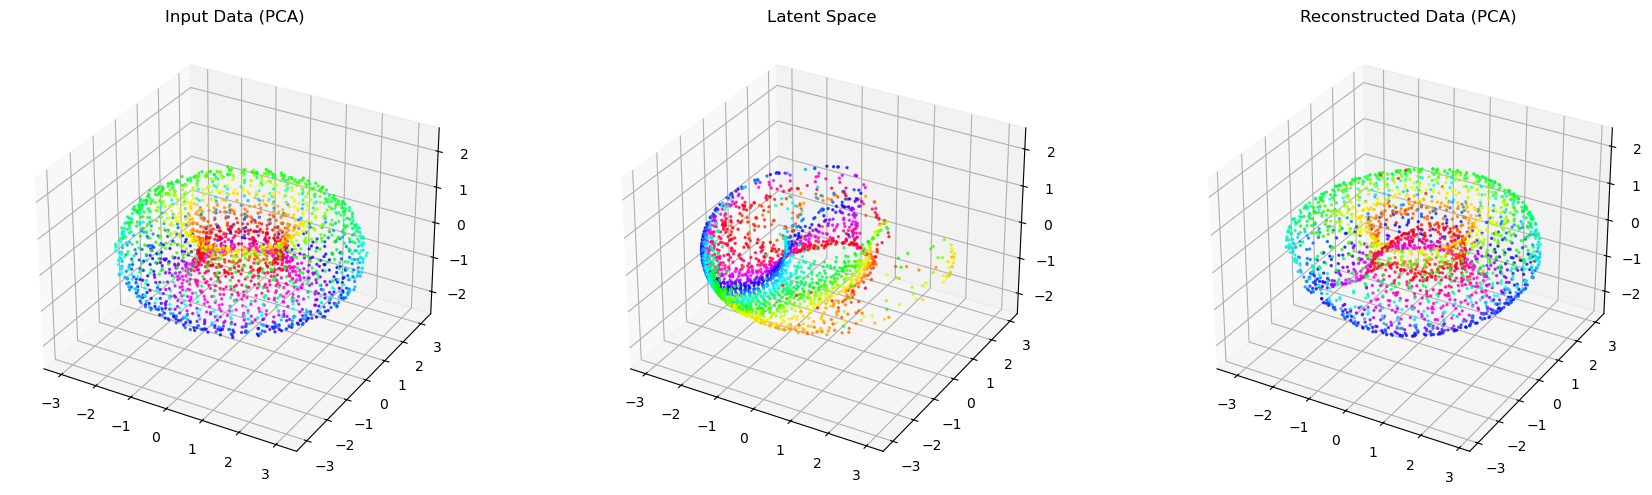

Execution time exp02_toroidal_VAE: 1303.4365 seconds

Running exp03_toroidal_VAE. 
Description: encoder_widths=[50, 50, 50], decoder_widths=[50, 50, 50], num_epochs=400, noise_var=0.001, activation=relu
--------------------------------------------------------------------------------------


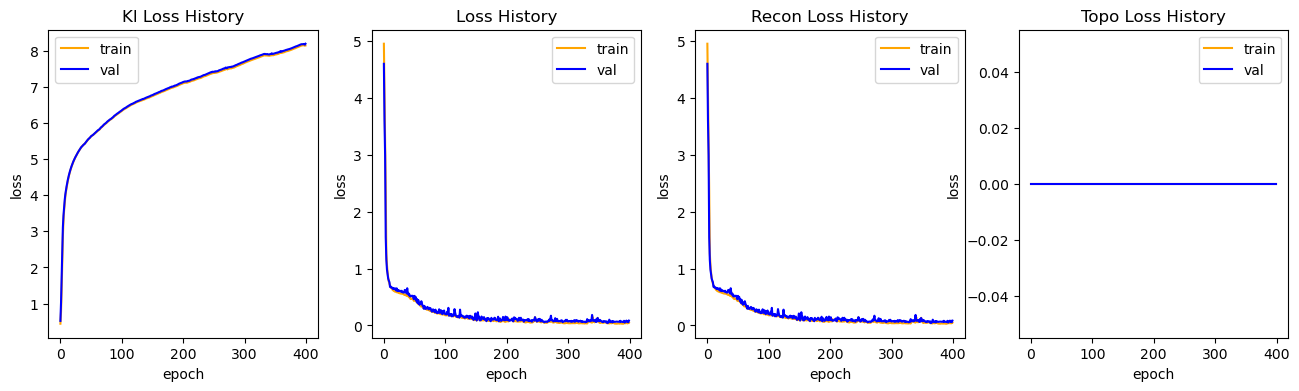

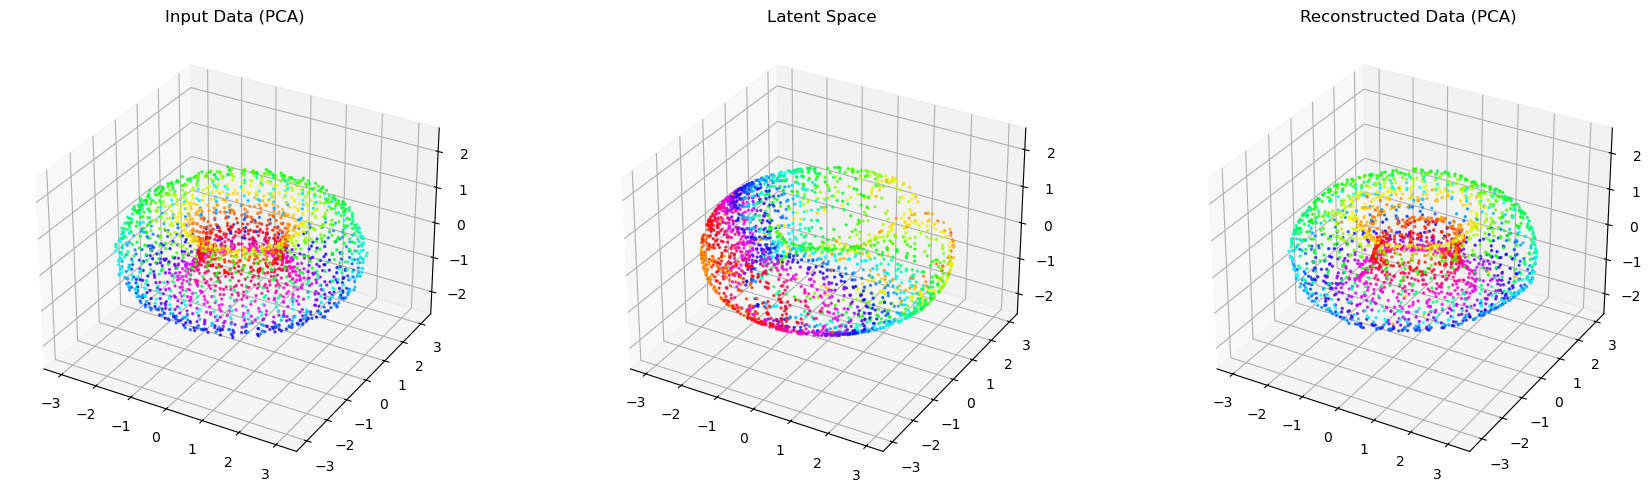

Execution time exp03_toroidal_VAE: 1518.2972 seconds

Running exp04_toroidal_VAE. 
Description: encoder_widths=[100, 100, 100], decoder_widths=[100, 100, 100], num_epochs=400, noise_var=0.001, activation=relu
--------------------------------------------------------------------------------------


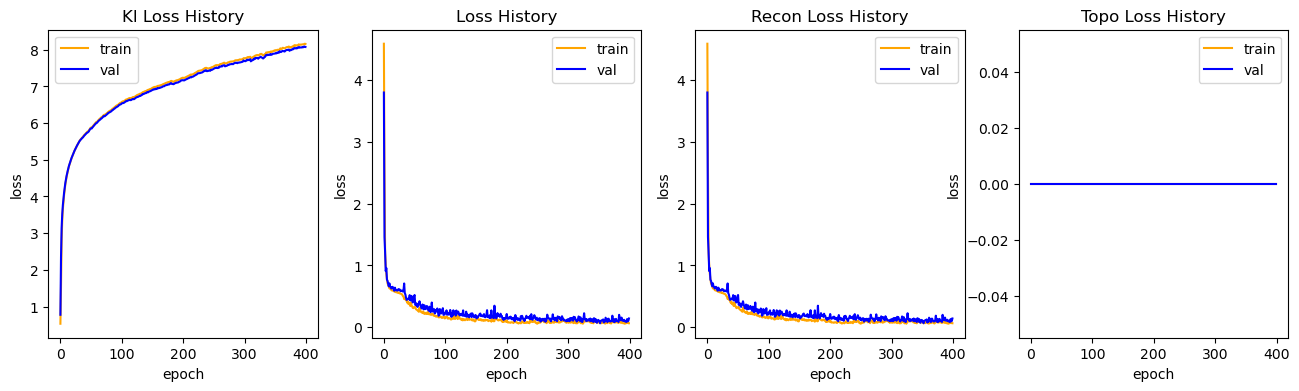

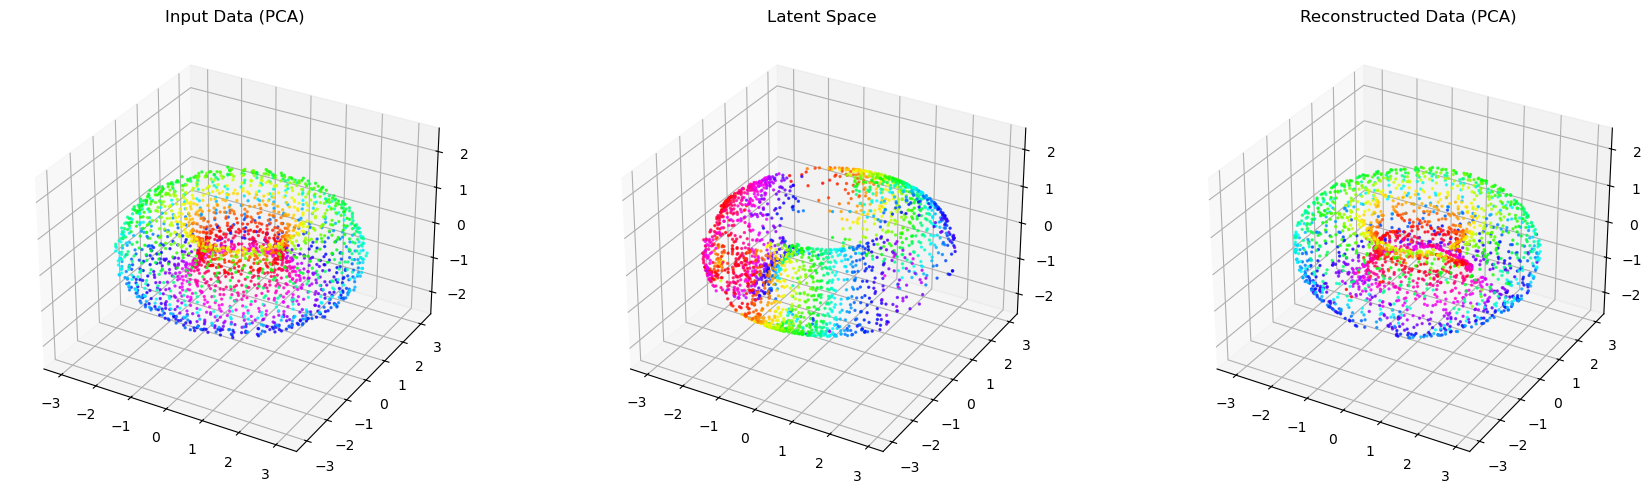

Execution time exp04_toroidal_VAE: 1764.0969 seconds

Running exp05_toroidal_VAE. 
Description: encoder_widths=[400, 400, 400], decoder_widths=[200, 200, 200], num_epochs=400, noise_var=0.001, activation=relu
--------------------------------------------------------------------------------------


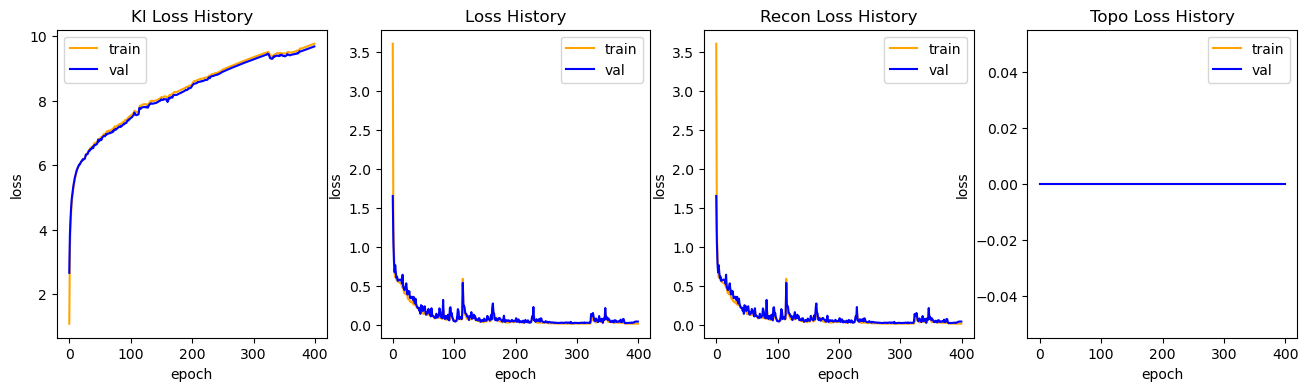

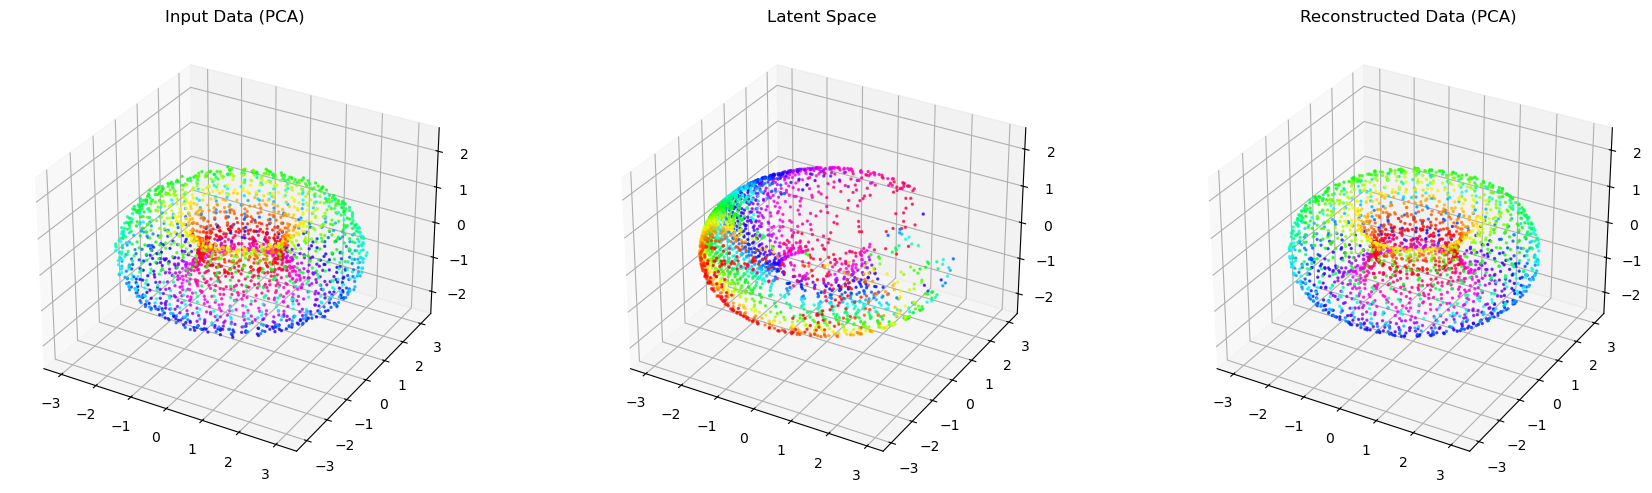

Execution time exp05_toroidal_VAE: 2072.7081 seconds


In [4]:
run_experiment(all_configs=all_configs)
